# Instructor Surface Viewer — Final Overshoot Version

This notebook imports the shared `hidden_system.py` file from the same folder, so the notebook and Streamlit app stay aligned.

This version is tuned so that:
- A and B dominate broad screening
- Filter is weak and usually held fixed in Phase II
- the first local A/B box naturally points to the upper-right corner
- an aggressive push toward the upper-right boundary tends to overstep, making re-boxing feel natural


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from hidden_system import (
    FILTER_CENTER,
    FILTER_MAX,
    FILTER_MIN,
    LED_MAX,
    LED_MIN,
    PRESSURE_MAX,
    PRESSURE_MIN,
    generate_hidden_model,
    model_summary,
    predict_noiseless_score,
    real_to_coded,
)


In [3]:
student_id = "demo_final_2026"
model = generate_hidden_model(student_id)
summary = model_summary(model)
summary


{'family_index': 3,
 'family_name': 'pressure_skewed',
 'beta0': 60.2091474145117,
 'betaA': 9.538687186821846,
 'betaB': 12.4447503620504,
 'betaC': -0.018195430466022382,
 'betaAB': -0.5783547909471625,
 'betaAC': 0.007211717714032281,
 'betaBC': 0.0004782589049685121,
 'qA': 8.497966905500924,
 'qB': 9.016117783254757,
 'qC': 0.3801577737043695,
 'sigma': 0.8873211286302377,
 'AB_stationary_coded': (0.538336291261332, 0.6728728084826885),
 'AB_stationary_real': (18.307, 19.056),
 'center_score_true': 60.209,
 'high_high_score_true': 64.1,
 'broad_curvature_gap_true': 17.894,
 'local_upper_right_true': 66.824,
 'suggested_rebox_center_true': 66.936,
 'aggressive_overshoot_true': 65.578}

In [4]:
def score_real(model, led, pressure, filt=FILTER_CENTER):
    xA, xB, xC = real_to_coded(led, pressure, filt)
    return predict_noiseless_score(model, xA, xB, xC)


def center_slice_grid(model, filt_value=FILTER_CENTER, n=250):
    led_grid = np.linspace(LED_MIN, LED_MAX, n)
    pressure_grid = np.linspace(PRESSURE_MIN, PRESSURE_MAX, n)
    LL, PP = np.meshgrid(led_grid, pressure_grid)
    xA = (LL - 14.0) / 8.0
    xB = (PP - 13.0) / 9.0
    xC = (filt_value - 9.0) / 8.0
    Z = predict_noiseless_score(model, xA, xB, xC)
    return LL, PP, Z


local_box = np.array([
    [14.0, 14.0],
    [18.0, 14.0],
    [14.0, 18.0],
    [18.0, 18.0],
])

rebox_center = (18.5, 19.5)
aggressive_overshoot = (20.0, 22.0)


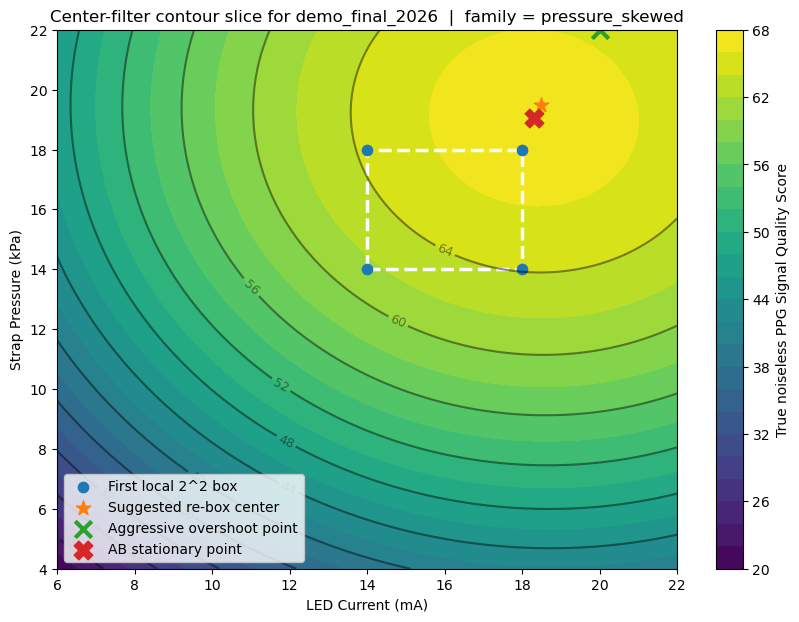

In [8]:
LL, PP, Z = center_slice_grid(model, FILTER_CENTER)
fig, ax = plt.subplots(figsize=(10, 7))

cf = ax.contourf(LL, PP, Z, levels=24)
cs = ax.contour(LL, PP, Z, levels=12, colors='k', alpha=0.45)
ax.clabel(cs, inline=True, fontsize=9)

# First local 2^2 box around (16,16)
ax.add_patch(Rectangle((14, 14), 4, 4, fill=False, linewidth=2.5, linestyle='--', edgecolor='white'))
ax.scatter(local_box[:, 0], local_box[:, 1], s=55, label='First local 2^2 box')

# Mark the natural next-region logic
ax.scatter(*rebox_center, s=120, marker='*', label='Suggested re-box center')
ax.scatter(*aggressive_overshoot, s=140, marker='x', linewidths=3, label='Aggressive overshoot point')

stationary = summary['AB_stationary_real']
if stationary is not None:
    ax.scatter(stationary[0], stationary[1], s=180, marker='X', label='AB stationary point')

ax.set_title(f"Center-filter contour slice for {student_id}  |  family = {model.family_name}")
ax.set_xlabel('LED Current (mA)')
ax.set_ylabel('Strap Pressure (kPa)')
ax.set_xlim(LED_MIN, LED_MAX)
ax.set_ylim(PRESSURE_MIN, PRESSURE_MAX)
ax.legend(loc='lower left')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('True noiseless PPG Signal Quality Score')
plt.show()


In [10]:
points = [
    ('Broad center', 14.0, 13.0),
    ('Local box center', 16.0, 16.0),
    ('Local corner (14,14)', 14.0, 14.0),
    ('Local corner (18,14)', 18.0, 14.0),
    ('Local corner (14,18)', 14.0, 18.0),
    ('Local corner (18,18)', 18.0, 18.0),
    ('Suggested re-box center', 18.5, 19.5),
    ('Aggressive overshoot', 20.0, 22.0),
]

rows = []
for label, led, pressure in points:
    rows.append({
        'Point': label,
        'LED_mA': led,
        'Pressure_kPa': pressure,
        'Filter_samples': FILTER_CENTER,
        'True_score': round(score_real(model, led, pressure, FILTER_CENTER), 3),
    })

pd.DataFrame(rows)


,Point,LED_mA,Pressure_kPa,Filter_samples,True_score
0,Broad center,14.0,13.0,9.0,60.209
1,Local box center,16.0,16.0,9.0,65.161
2,"Local corner (14,14)",14.0,14.0,9.0,61.481
3,"Local corner (18,14)",18.0,14.0,9.0,64.093
4,"Local corner (14,18)",14.0,18.0,9.0,64.340
5,"Local corner (18,18)",18.0,18.0,9.0,66.824
6,Suggested re-box center,18.5,19.5,9.0,66.936
7,Aggressive overshoot,20.0,22.0,9.0,65.578


In [12]:
# Optional: compare multiple IDs quickly
id_list = ["demo_A", "demo_B", "demo_C", "demo_D", "demo_E", "demo_F"]

for sid in id_list:
    m = generate_hidden_model(sid)
    s = model_summary(m)
    print(
        f"{sid:10s} | family = {m.family_name:18s} | "
        f"AB stationary real = {s['AB_stationary_real']} | "
        f"18,18 = {s['local_upper_right_true']:.2f} | "
        f"re-box = {s['suggested_rebox_center_true']:.2f} | "
        f"20,22 = {s['aggressive_overshoot_true']:.2f}"
    )


demo_A     | family = pressure_skewed    | AB stationary real = (18.463, 19.014) | 18,18 = 68.23 | re-box = 68.34 | 20,22 = 67.11
demo_B     | family = centered_broad     | AB stationary real = (18.921, 18.83) | 18,18 = 66.42 | re-box = 66.54 | 20,22 = 65.33
demo_C     | family = pressure_skewed    | AB stationary real = (17.475, 19.283) | 18,18 = 65.98 | re-box = 66.06 | 20,22 = 64.63
demo_D     | family = centered_broad     | AB stationary real = (18.831, 18.689) | 18,18 = 66.78 | re-box = 66.84 | 20,22 = 65.50
demo_E     | family = centered_broad     | AB stationary real = (19.1, 18.599) | 18,18 = 68.77 | re-box = 68.82 | 20,22 = 67.59
demo_F     | family = rotated_northeast  | AB stationary real = (18.203, 19.11) | 18,18 = 68.76 | re-box = 68.87 | 20,22 = 67.75
